In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Online Retail.csv")

### Exploratory Data Analysis (EDA)

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


In [5]:
df.shape

(541909, 8)

In [6]:
df.isna().sum()

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,540455.000000,540455.000000,540455.000000
mean,9.603129,4.623519,15287.519829
std,218.007598,96.889628,1486.741928
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,14364.000000
50%,3.000000,2.080000,15287.000000
75%,10.000000,4.130000,16261.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [11]:
df = df.drop_duplicates()

In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['TotalPrice'].head()

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: TotalPrice, dtype: float64

In [15]:
df['CustomerID'].isnull().sum()

np.int64(0)

In [16]:
df['Description'].isnull().sum()

np.int64(0)

In [17]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [18]:
df.shape

(524878, 9)

In [19]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

In [20]:
df.nunique()

InvoiceNo      19960
StockCode       3922
Description     4026
Quantity         375
InvoiceDate    18499
UnitPrice       1291
CustomerID      4338
Country           38
TotalPrice      4906
dtype: int64

In [21]:
df['TotalPrice'].sum()

np.float64(10642110.804000001)

In [22]:
df.groupby('InvoiceNo')['TotalPrice'].sum().mean()

np.float64(533.1718839679359)

In [23]:
df.groupby('InvoiceNo')['TotalPrice'].sum().max()

np.float64(168469.6)

In [24]:
df.groupby('InvoiceNo')['TotalPrice'].sum().min()

np.float64(0.38)

In [25]:
top_products = df.groupby('Description')['Quantity'] .sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [26]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_sales.head(7)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Name: TotalPrice, dtype: float64

In [27]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
15287    1755388.60
14646     280206.02
18102     259657.30
17450     194390.79
16446     168472.50
14911     143711.17
12415     124914.53
14156     117210.08
17511      91062.38
16029      80850.84
Name: TotalPrice, dtype: float64

In [28]:
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)
orders_per_customer.head(10)

CustomerID
15287    1430
12748     209
14911     201
17841     124
13089      97
14606      93
15311      91
12971      86
14646      73
16029      63
Name: InvoiceNo, dtype: int64

In [29]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

In [30]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

In [31]:
df.shape

(524878, 13)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  int64         
 7   Country      524878 non-null  object        
 8   TotalPrice   524878 non-null  float64       
 9   Year         524878 non-null  int32         
 10  Month        524878 non-null  int32         
 11  Day          524878 non-null  int32         
 12  Hour         524878 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(4), int64(2), object(4)
memory usage: 48.1+ MB


In [33]:
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum()
monthly_sales

Year  Month
2010  12        821452.730
2011  1         689811.610
      2         522545.560
      3         716215.260
      4         536968.491
      5         769296.610
      6         760547.010
      7         718076.121
      8         757841.380
      9        1056435.192
      10       1151263.730
      11       1503866.780
      12        637790.330
Name: TotalPrice, dtype: float64

### Market Basket Analysis

In [34]:
df['Description'] = df['Description'].str.strip()

In [35]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket.head()

Description,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
basket = basket.map(lambda x: 1 if x > 0 else 0)
basket.head()

Description,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
from mlxtend.frequent_patterns import apriori, association_rules
basket = basket.astype(bool)
frequent_items = apriori(basket,min_support=0.02,use_colnames=True,low_memory=True)
frequent_items.head()

,support,itemsets
0,0.023447,(3 STRIPEY MICE FELTCRAFT)
1,0.024198,(4 TRADITIONAL SPINNING TOPS)
2,0.047846,(6 RIBBONS RUSTIC CHARM)
3,0.021894,(60 CAKE CASES DOLLY GIRL DESIGN)
4,0.030962,(60 CAKE CASES VINTAGE CHRISTMAS)


In [38]:
rules = association_rules(frequent_items, metric="lift", min_threshold=1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(PACK OF 72 RETROSPOT CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.066132,0.041483,0.022695,0.343182,8.272837,1.0,0.019952,1.459334,0.941378,0.267257,0.314756,0.445142
1,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.041483,0.066132,0.022695,0.547101,8.272837,1.0,0.019952,2.061980,0.917169,0.267257,0.515029,0.445142
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.039228,0.049098,0.020942,0.533844,10.872990,1.0,0.019016,2.039880,0.945104,0.310781,0.509775,0.480187
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.049098,0.039228,0.020942,0.426531,10.872990,1.0,0.019016,1.675367,0.954914,0.310781,0.403116,0.480187
4,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.049098,0.052655,0.032064,0.653061,12.402571,1.0,0.029479,2.730582,0.966842,0.460101,0.633778,0.631003


In [39]:
rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.5)]
rules.sort_values(by='lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.038327,0.038427,0.027104,0.707190,18.403524,1.0,0.025631,3.283944,0.983351,0.545913,0.695488,0.706268
159,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.038427,0.038327,0.027104,0.705346,18.403524,1.0,0.025631,3.263732,0.983454,0.545913,0.693602,0.706268
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029960,0.050752,0.027104,0.904682,17.825724,1.0,0.025584,9.958782,0.973054,0.505607,0.899586,0.719370
161,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.050752,0.029960,0.027104,0.534057,17.825724,1.0,0.025584,2.081887,0.994367,0.505607,0.519667,0.719370
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038327,0.050752,0.031663,0.826144,16.278213,1.0,0.029718,5.459963,0.975974,0.551483,0.816849,0.725017


### Recommendation System

In [40]:
rules['score'] = rules['confidence'] * rules['lift']

In [41]:
def recommend_top(product, n=5):
    product = product.strip().upper()
    
    result = rules[
        rules['antecedents'].apply(lambda x: product in [i.upper() for i in x])
    ]
    
    return result.sort_values(by='lift', ascending=False).head(n)

In [42]:
recommend_top("ALARM CLOCK BAKELIKE PINK")

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
6,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.039228,0.052655,0.023547,0.600255,11.399713,1.0,0.021482,2.369875,0.949527,0.344575,0.578037,0.523724,6.842740
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.039228,0.049098,0.020942,0.533844,10.872990,1.0,0.019016,2.039880,0.945104,0.310781,0.509775,0.480187,5.804482


In [43]:
recommend_top("PINK REGENCY TEACUP AND SAUCER")

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.038327,0.038427,0.027104,0.707190,18.403524,1.0,0.025631,3.283944,0.983351,0.545913,0.695488,0.706268,13.014780
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029960,0.050752,0.027104,0.904682,17.825724,1.0,0.025584,9.958782,0.973054,0.505607,0.899586,0.719370,16.126616
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038327,0.050752,0.031663,0.826144,16.278213,1.0,0.029718,5.459963,0.975974,0.551483,0.816849,0.725017,13.448145
158,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.031663,0.053357,0.027104,0.856013,16.043204,1.0,0.025415,6.574490,0.968329,0.467993,0.847897,0.681997,13.733186
140,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.038327,0.053357,0.029960,0.781699,14.650440,1.0,0.027915,4.336420,0.968876,0.485390,0.769395,0.671601,11.452240


In [44]:
rules['score'] = rules['confidence'] * rules['lift']

In [45]:
def smart_recommend(product, n=5):
    product = product.strip().upper()
    
    result = rules[
        rules['antecedents'].apply(lambda x: product in [i.upper() for i in x])
    ]
    
    return result.sort_values(by='score', ascending=False).head(n)

In [46]:
smart_recommend("ALARM CLOCK BAKELIKE PINK")

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
6,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.039228,0.052655,0.023547,0.600255,11.399713,1.0,0.021482,2.369875,0.949527,0.344575,0.578037,0.523724,6.842740
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.039228,0.049098,0.020942,0.533844,10.872990,1.0,0.019016,2.039880,0.945104,0.310781,0.509775,0.480187,5.804482


### Customer Segmentation (RFM) ( Recency , Frequency , Monetary )

In [47]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [48]:
rfm.sort_values(by='Monetary', ascending=False).head()

,Recency,Frequency,Monetary
CustomerID,,,
15287,1,1430,1755388.60
14646,2,73,280206.02
18102,1,60,259657.30
17450,8,46,194390.79
16446,1,2,168472.50


In [49]:
rfm.sort_values(by='Frequency', ascending=False).head()

,Recency,Frequency,Monetary
CustomerID,,,
15287,1,1430,1755388.60
12748,1,209,33053.19
14911,1,201,143711.17
17841,2,124,40519.84
13089,3,97,58762.08


In [50]:
rfm.sort_values(by='Recency', ascending=True).head()

,Recency,Frequency,Monetary
CustomerID,,,
13599,1,21,5149.92
12433,1,7,13375.87
13013,1,13,4810.94
12985,1,2,1239.38
13026,1,5,975.36


In [51]:
rfm.sort_values(by=['Monetary', 'Frequency'], ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
15287,1,1430,1755388.60
14646,2,73,280206.02
18102,1,60,259657.30
17450,8,46,194390.79
16446,1,2,168472.50
14911,1,201,143711.17
12415,24,21,124914.53
14156,10,55,117210.08
17511,3,31,91062.38


###  Advanced Customer Segmentation (K-Means Clustering)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

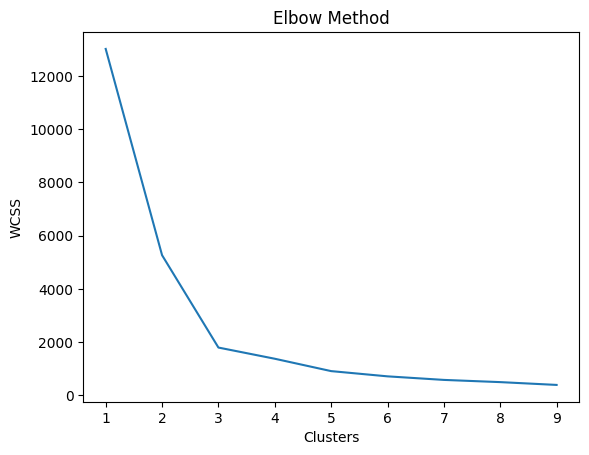

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [54]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [57]:
rfm.groupby('Cluster').mean()
###  Cluster 0
   ### Low Recency , High Frequency , High Monetary Value  ( VIP Customers )
###  Cluster 1
   ### Moderate Frequency  ( Regular Customers )
###  Cluster 2
   ### High Recency (Inactive Customers)    ( At-Risk Customers ) 
###  Cluster 3
   ### Low Frequency & Low Monetary Value   ( New / Low-Value Customers )


,Recency,Frequency,Monetary
Cluster,,,
0,41.784568,4.652469,1.840114e+03
1,1.000000,1430.000000,1.755389e+06
2,248.237162,1.614379,6.473152e+02
3,6.038462,66.423077,8.582608e+04
